# Week 5 Mystery Ops Diagnostics Analysis

This notebook investigates the Mystery Ops dataset using a structured operational diagnostics workflow. The analysis moves from profiling the full dataset to isolating anomalies, drilling into the highest-impact locations and causes, and then validating likely drivers with correlation checks.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path
from scipy.stats import zscore

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

# Load the dataset from the repository structure.
data_path = Path('Week5/Mystery_Ops.csv')
if not data_path.exists():
    data_path = Path('Mystery_Ops.csv')

df = pd.read_csv(data_path)

# Parse the date field and prepare a working analysis frame.
df['operation_date'] = pd.to_datetime(df['operation_date'], format='%d/%m/%Y', errors='coerce')
df['incident_type'] = df['incident_type'].fillna('none')

analysis_df = df.copy()
analysis_df['operator_id'] = analysis_df['operator_id'].fillna('UNKNOWN')
analysis_df['temperature_c'] = analysis_df.groupby('depot')['temperature_c'].transform(lambda s: s.fillna(s.median()))
analysis_df['throughput_barrels'] = analysis_df.groupby('depot')['throughput_barrels'].transform(lambda s: s.fillna(s.median()))
analysis_df['month'] = analysis_df['operation_date'].dt.to_period('M').astype(str)
analysis_df['day_of_week'] = analysis_df['operation_date'].dt.day_name()

for col in ['depot', 'shift', 'incident_type', 'machine_id']:
    analysis_df[col] = analysis_df[col].astype('category')

analysis_df.head()

,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type,month,day_of_week
0,MO-20260224-MOM-D,2026-02-24,Mombasa,Day,OP-M02,MBA-P01,1069.7,34.6,0,230,none,2026-02,Tuesday
1,MO-20261015-KIS-D,2026-10-15,Kisumu,Day,OP-K01,KSM-P01,1051.6,25.5,0,227,none,2026-10,Thursday
2,MO-20260518-MOM-D,2026-05-18,Mombasa,Day,OP-M04,MBA-P01,999.3,37.1,0,209,none,2026-05,Monday
3,MO-20260209-MOM-N,2026-02-09,Mombasa,Night,OP-M04,MBA-P03,1038.7,32.4,0,213,none,2026-02,Monday
4,MO-20260318-MOM-N,2026-03-18,Mombasa,Night,OP-M02,MBA-P01,939.7,34.5,0,225,none,2026-03,Wednesday


## 1. Univariate profiling

The first step is to understand the overall shape of the data. Summary statistics, missing-value checks, and distributions help reveal whether the issue is a broad performance drift or a narrow set of unusual records.

In [6]:
# Numeric summary statistics.
summary = analysis_df[['throughput_barrels', 'temperature_c', 'voltage_count', 'maintenance_flag']].describe().T
summary

,count,mean,std,min,25%,50%,75%,max
throughput_barrels,2920.0,917.013938,168.004685,296.5,873.35,969.65,1029.6,1210.6
temperature_c,2920.0,25.041062,5.549676,10.9,21.20,25.10,29.1,39.9
voltage_count,2920.0,221.122945,6.518187,197.0,217.00,221.00,225.0,242.0
maintenance_flag,2920.0,0.186644,0.389692,0.0,0.00,0.00,0.0,1.0


In [7]:
# Missing values by column and percent of total rows.
missing_summary = pd.DataFrame({
    'missing_count': analysis_df.isna().sum(),
    'missing_pct': (analysis_df.isna().mean() * 100).round(2)
})
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct


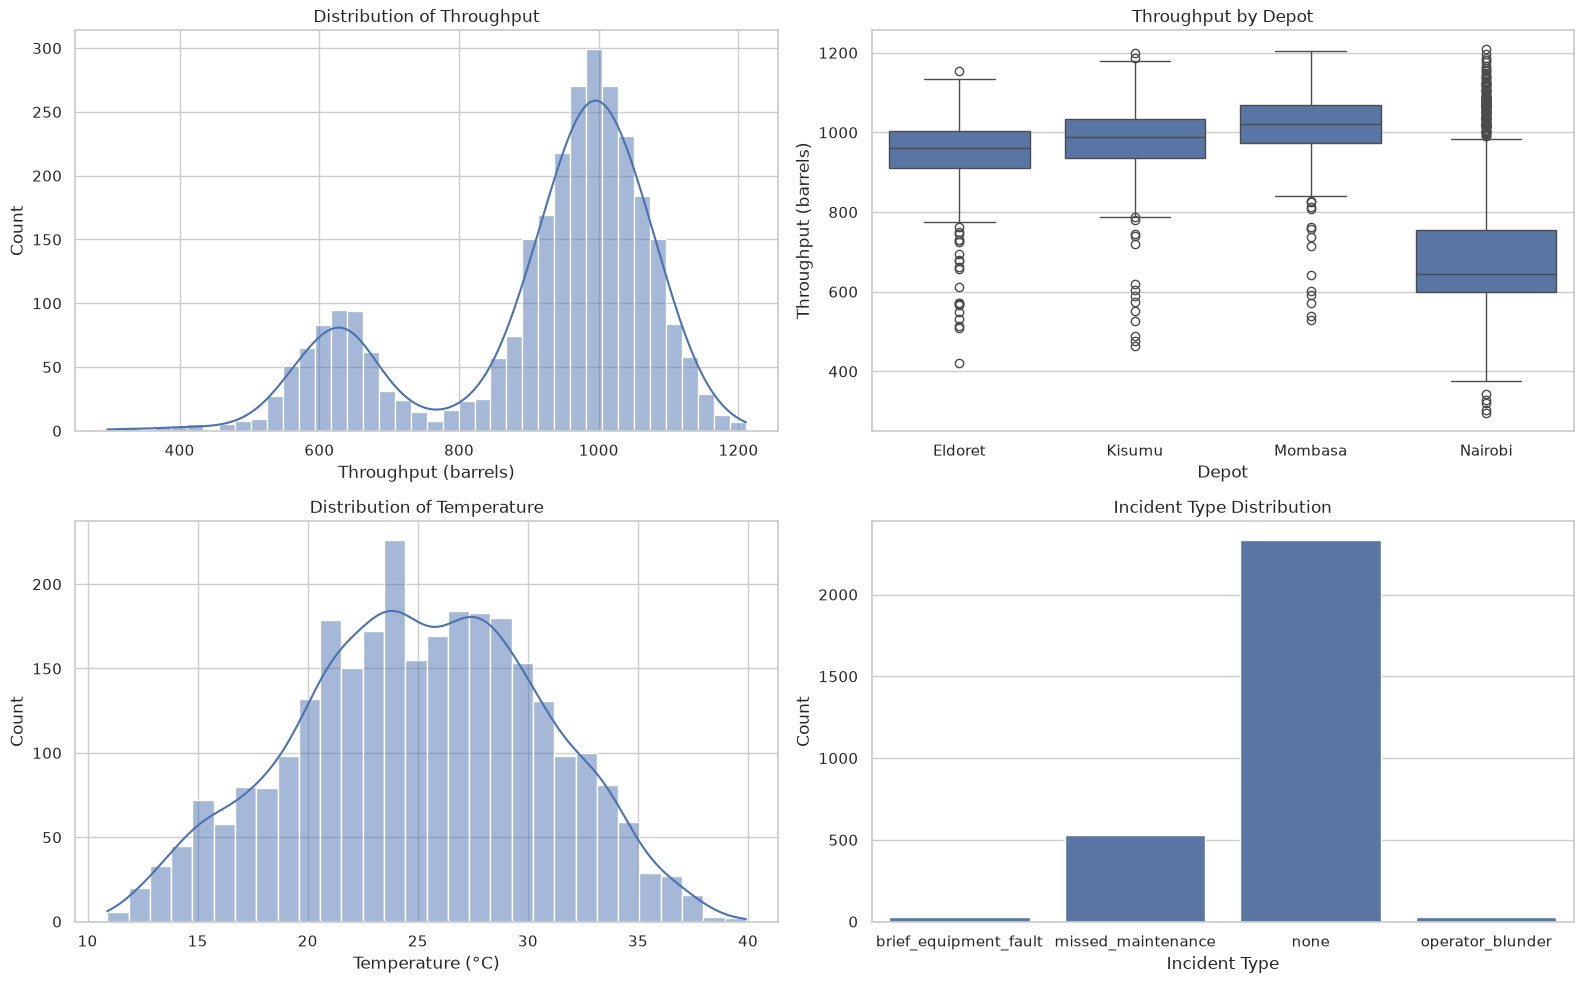

In [8]:
# Distribution plots for the core operational KPI.
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(analysis_df['throughput_barrels'], bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Throughput')
axes[0, 0].set_xlabel('Throughput (barrels)')

sns.boxplot(data=analysis_df, x='depot', y='throughput_barrels', ax=axes[0, 1])
axes[0, 1].set_title('Throughput by Depot')
axes[0, 1].set_xlabel('Depot')
axes[0, 1].set_ylabel('Throughput (barrels)')

sns.histplot(analysis_df['temperature_c'], bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Temperature')
axes[1, 0].set_xlabel('Temperature (°C)')

sns.countplot(data=analysis_df, x='incident_type', ax=axes[1, 1])
axes[1, 1].set_title('Incident Type Distribution')
axes[1, 1].set_xlabel('Incident Type')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 2. Bivariate profiling

The next question is whether the main KPI changes systematically with operational conditions. Comparing throughput against time, depot, maintenance, and environmental variables helps distinguish structural breakage from normal variation.

In [9]:
# Correlation matrix for numeric variables.
correlation_columns = ['throughput_barrels', 'temperature_c', 'voltage_count', 'maintenance_flag']
correlation_matrix = analysis_df[correlation_columns].corr().round(3)
correlation_matrix

,throughput_barrels,temperature_c,voltage_count,maintenance_flag
throughput_barrels,1.000,0.252,0.039,-0.853
temperature_c,0.252,1.000,-0.004,-0.125
voltage_count,0.039,-0.004,1.000,0.019
maintenance_flag,-0.853,-0.125,0.019,1.000


In [10]:
# Scatter plot of throughput versus temperature, colored by maintenance flag.
fig = px.scatter(
    analysis_df,
    x='temperature_c',
    y='throughput_barrels',
    color='maintenance_flag',
    symbol='depot',
    hover_data=['incident_type', 'machine_id', 'month'],
    title='Throughput vs Temperature by Depot and Maintenance Flag',
    labels={'throughput_barrels': 'Throughput (barrels)', 'temperature_c': 'Temperature (°C)'}
)
fig.update_layout(template='plotly_white', width=900, height=500)
fig.show()

In [11]:
# Monthly average throughput by depot.
monthly_trend = analysis_df.groupby(['month', 'depot'])['throughput_barrels'].mean().reset_index()
fig = px.line(
    monthly_trend,
    x='month',
    y='throughput_barrels',
    color='depot',
    markers=True,
    title='Monthly Throughput Trend by Depot',
    labels={'throughput_barrels': 'Average Throughput (barrels)', 'month': 'Month'}
)
fig.update_layout(template='plotly_white', width=1000, height=500)
fig.show()

## 3. Anomaly detection

This section flags records that are unusually far from the expected throughput range. These points are important because they can either represent a genuine operational fault or a data-quality issue that needs to be isolated before the root cause is concluded.

In [12]:
# IQR and z-score based anomaly detection for throughput.
q1 = analysis_df['throughput_barrels'].quantile(0.25)
q3 = analysis_df['throughput_barrels'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

analysis_df['iqr_outlier'] = analysis_df['throughput_barrels'].lt(lower_bound) | analysis_df['throughput_barrels'].gt(upper_bound)
analysis_df['zscore_throughput'] = zscore(analysis_df['throughput_barrels'])
analysis_df['zscore_outlier'] = analysis_df['zscore_throughput'].abs() > 3
analysis_df['anomaly_flag'] = analysis_df['iqr_outlier'] | analysis_df['zscore_outlier']

significant_anomalies = analysis_df[analysis_df['anomaly_flag']].copy()
significant_anomalies = significant_anomalies.sort_values('zscore_throughput').head(15)
significant_anomalies[['record_id', 'depot', 'machine_id', 'operation_date', 'throughput_barrels', 'incident_type', 'maintenance_flag', 'temperature_c', 'voltage_count']]

,record_id,depot,machine_id,operation_date,throughput_barrels,incident_type,maintenance_flag,temperature_c,voltage_count
313,MO-20260302-NAI-N,Nairobi,NBI-P03,2026-03-02,296.5,brief_equipment_fault,1,28.0,219
142,MO-20261014-NAI-N,Nairobi,NBI-P03,2026-10-14,302.8,brief_equipment_fault,1,20.3,217
2605,MO-20261004-NAI-N,Nairobi,NBI-P03,2026-10-04,319.5,brief_equipment_fault,1,18.3,214
1409,MO-20260830-NAI-N,Nairobi,NBI-P03,2026-08-30,328.8,brief_equipment_fault,1,23.5,214
2067,MO-20260923-NAI-D,Nairobi,NBI-P03,2026-09-23,342.0,brief_equipment_fault,1,18.3,212
1524,MO-20260515-NAI-D,Nairobi,NBI-P03,2026-05-15,376.6,operator_blunder,1,26.1,224
833,MO-20260324-NAI-D,Nairobi,NBI-P03,2026-03-24,381.0,operator_blunder,1,27.9,226
297,MO-20260825-NAI-D,Nairobi,NBI-P03,2026-08-25,384.3,brief_equipment_fault,1,19.3,229
2553,MO-20260415-NAI-D,Nairobi,NBI-P03,2026-04-15,394.7,brief_equipment_fault,1,28.8,224
502,MO-20260507-NAI-D,Nairobi,NBI-P03,2026-05-07,402.6,operator_blunder,1,23.9,231


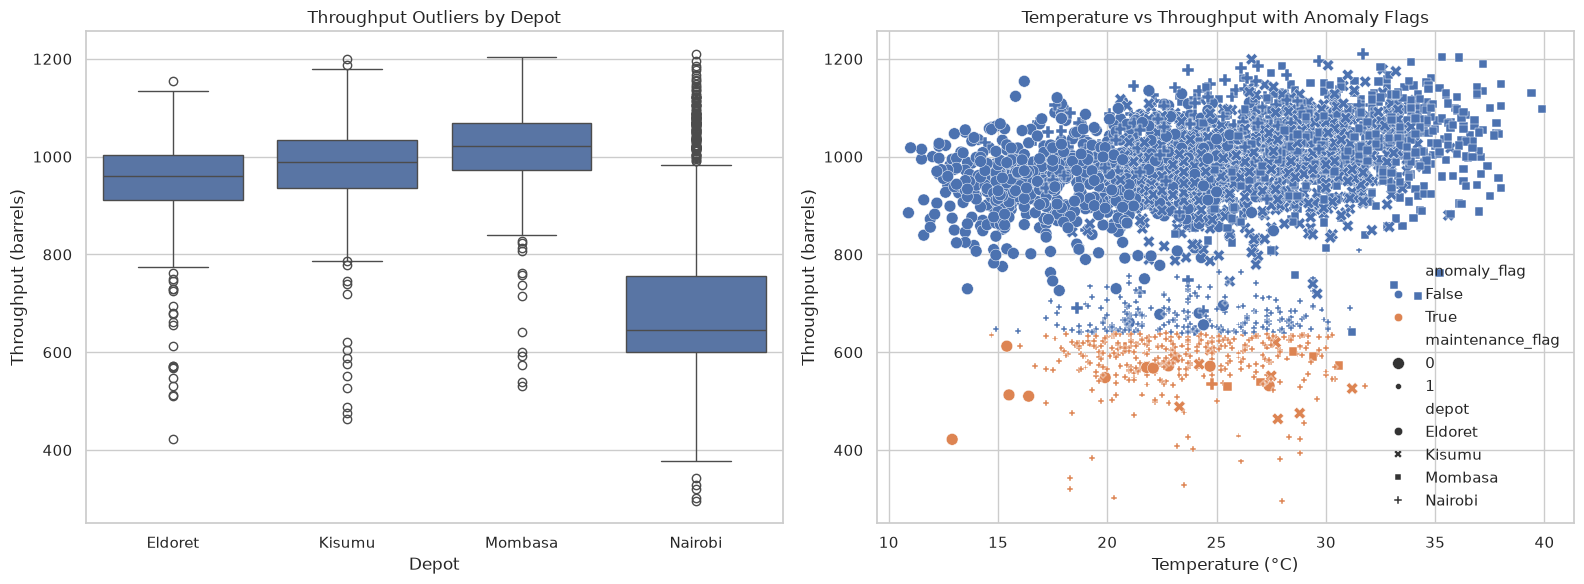

In [13]:
# Visualize anomalies with boxplots and scatter plots.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=analysis_df, x='depot', y='throughput_barrels', ax=axes[0])
axes[0].set_title('Throughput Outliers by Depot')
axes[0].set_xlabel('Depot')
axes[0].set_ylabel('Throughput (barrels)')

sns.scatterplot(
    data=analysis_df,
    x='temperature_c',
    y='throughput_barrels',
    hue='anomaly_flag',
    style='depot',
    size='maintenance_flag',
    ax=axes[1]
)
axes[1].set_title('Temperature vs Throughput with Anomaly Flags')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Throughput (barrels)')

plt.tight_layout()
plt.show()

## 4. Drill-down by time, location, and category

The anomalies are easier to interpret when the data is broken down by depot, month, machine, and incident type. This helps determine whether the issue is concentrated in one place, one machine, or one operating condition.

In [14]:
# Drill-down by depot and machine to isolate the main hotspot.
drilldown = analysis_df.groupby(['depot', 'machine_id', 'incident_type']).agg(
    avg_throughput=('throughput_barrels', 'mean'),
    records=('record_id', 'count'),
    maintenance_events=('maintenance_flag', 'sum')
).reset_index()

drilldown.sort_values(['depot', 'avg_throughput']).head(20)

,depot,machine_id,incident_type,avg_throughput,records,maintenance_events
3,Eldoret,ELD-P02,brief_equipment_fault,476.650000,2,0
5,Eldoret,ELD-P02,operator_blunder,511.400000,2,0
8,Eldoret,ELD-P03,operator_blunder,548.200000,1,0
6,Eldoret,ELD-P03,brief_equipment_fault,590.650000,2,0
0,Eldoret,ELD-P01,brief_equipment_fault,614.050000,2,0
2,Eldoret,ELD-P01,operator_blunder,631.460000,5,0
1,Eldoret,ELD-P01,none,953.670161,248,0
7,Eldoret,ELD-P03,none,956.365801,231,0
4,Eldoret,ELD-P02,none,966.860759,237,0
14,Kisumu,KSM-P03,brief_equipment_fault,516.325000,4,0


In [15]:
# Monthly averages by depot to show the timing of the throughput break.
monthly_breakdown = analysis_df.groupby(['month', 'depot', 'incident_type'])['throughput_barrels'].mean().reset_index()
monthly_breakdown.head()

,month,depot,incident_type,throughput_barrels
0,2026-01,Eldoret,brief_equipment_fault,568.900000
1,2026-01,Eldoret,none,963.444262
2,2026-01,Kisumu,none,980.754839
3,2026-01,Mombasa,none,1029.783607
4,2026-01,Mombasa,operator_blunder,737.600000


## 5. Pareto analysis

A Pareto view focuses effort on the largest contributors. Here the analysis ranks the factors with the biggest throughput impact so the investigation can target the dominant source rather than spread effort across many small issues.

In [17]:
# Estimate throughput loss against a depot-level baseline for normal operations.
normal_baseline = (
    analysis_df.loc[analysis_df['incident_type'].eq('none'), ['depot', 'throughput_barrels']]
    .groupby('depot', observed=False)['throughput_barrels']
    .median()
    .astype(float)
)
analysis_df['expected_throughput'] = analysis_df['depot'].astype(str).map(normal_baseline)
analysis_df['throughput_loss'] = (analysis_df['expected_throughput'] - analysis_df['throughput_barrels']).clip(lower=0)

pareto_source = analysis_df.groupby('machine_id').agg(
    total_loss=('throughput_loss', 'sum'),
    records=('record_id', 'count')
).reset_index().sort_values('total_loss', ascending=False)
pareto_source['cumulative_pct'] = pareto_source['total_loss'].cumsum() / pareto_source['total_loss'].sum() * 100
pareto_source.head(10)

,machine_id,total_loss,records,cumulative_pct
11,NBI-P03,235312.05,566,73.657829
0,ELD-P01,10318.10,255,76.887620
5,KSM-P03,10216.10,251,80.085483
3,KSM-P01,9264.80,250,82.985569
2,ELD-P03,8209.00,234,85.555165
6,MBA-P01,8186.20,244,88.117625
8,MBA-P03,8179.20,242,90.677894
7,MBA-P02,7706.50,244,93.090198
1,ELD-P02,7554.80,241,95.455016
4,KSM-P02,7185.10,229,97.704109


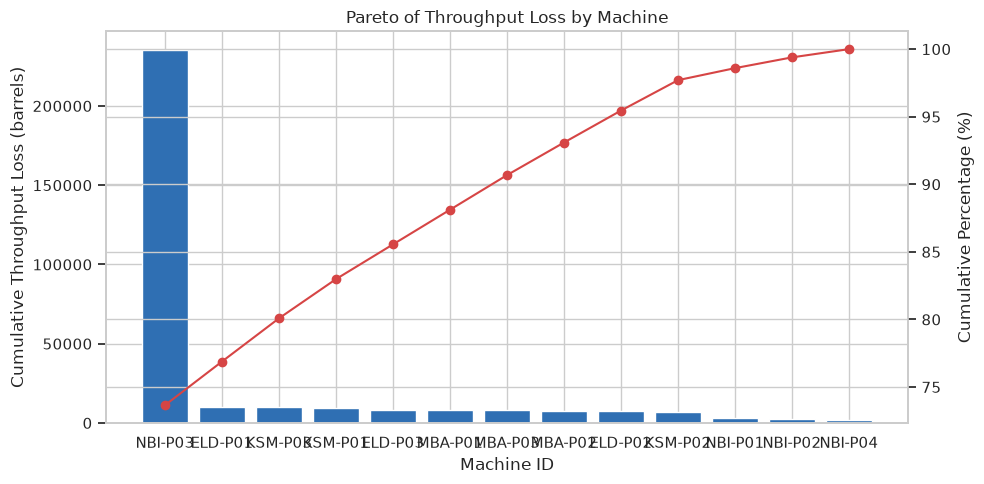

In [28]:
# Pareto chart for the highest-impact machines.
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pareto_source['machine_id'], pareto_source['total_loss'], color='#2F6FB3')
ax2 = ax.twinx()
ax2.plot(pareto_source['machine_id'], pareto_source['cumulative_pct'], color='#D64545', marker='o')
ax.set_title('Pareto of Throughput Loss by Machine')
ax.set_xlabel('Machine ID')
ax.set_ylabel('Cumulative Throughput Loss (barrels)')
ax2.set_ylabel('Cumulative Percentage (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Correlation and driver analysis

The investigation also needs to rule out or confirm plausible operational drivers. Temperature and voltage count are the obvious candidates in this dataset, but the goal is to test whether they explain the throughput drop or whether maintenance-related failure is the stronger driver.

In [19]:
# Focused correlation analysis for likely drivers.
driver_columns = ['throughput_barrels', 'temperature_c', 'voltage_count', 'maintenance_flag']
correlation_summary = analysis_df[driver_columns].corr()['throughput_barrels'].sort_values(ascending=False)
correlation_summary

throughput_barrels    1.000000
temperature_c         0.251697
voltage_count         0.039006
maintenance_flag     -0.852987
Name: throughput_barrels, dtype: float64

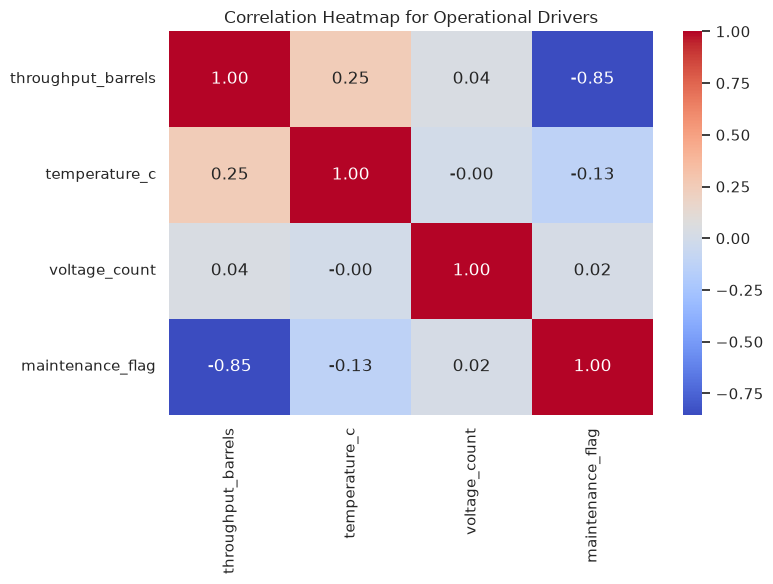

In [20]:
# Correlation heatmap for the main operational variables.
plt.figure(figsize=(8, 6))
sns.heatmap(
    analysis_df[driver_columns].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap for Operational Drivers')
plt.tight_layout()
plt.show()

## 7. Publication-quality visuals and findings

The final visuals synthesize the pattern into a clear story: a concentrated throughput collapse in Nairobi, most visible around the maintenance-related machine failure pattern, while temperature and voltage do not show the same strength as the operational fault signal.

In [21]:
# Publication-quality chart 1: throughput distribution by depot.
fig1 = px.box(
    analysis_df,
    x='depot',
    y='throughput_barrels',
    color='depot',
    title='Operational Throughput Distribution by Depot',
    labels={'throughput_barrels': 'Throughput (barrels)', 'depot': 'Depot'}
)
fig1.update_layout(template='plotly_white', width=900, height=500)
fig1.show()

In [22]:
# Publication-quality chart 2: monthly trend with anomaly context.
trend_with_anomaly = analysis_df.groupby(['month', 'depot']).agg(
    avg_throughput=('throughput_barrels', 'mean'),
    anomaly_count=('anomaly_flag', 'sum')
).reset_index()
fig2 = px.line(
    trend_with_anomaly,
    x='month',
    y='avg_throughput',
    color='depot',
    title='Monthly Throughput Trend with Anomaly Count Context',
    labels={'avg_throughput': 'Average Throughput (barrels)', 'month': 'Month'}
)
fig2.update_layout(template='plotly_white', width=1000, height=500)
fig2.show()

In [23]:
# Publication-quality chart 3: maintenance-related throughput loss by machine.
fig3 = px.bar(
    pareto_source.head(8),
    x='machine_id',
    y='total_loss',
    color='total_loss',
    title='Top Machines Contributing to Throughput Loss',
    labels={'machine_id': 'Machine ID', 'total_loss': 'Estimated Throughput Loss (barrels)'}
)
fig3.update_layout(template='plotly_white', width=900, height=500)
fig3.show()

In [24]:
# Key takeaway summary for the investigation.
print('Top anomaly records:')
print(significant_anomalies[['depot', 'machine_id', 'operation_date', 'throughput_barrels', 'incident_type']].head(10).to_string(index=False))
print('\nHighest-impact machine(s):')
print(pareto_source.head(5).to_string(index=False))
print('\nCorrelation with throughput:')
print(correlation_summary.to_string())

Top anomaly records:
  depot machine_id operation_date  throughput_barrels         incident_type
Nairobi    NBI-P03     2026-03-02               296.5 brief_equipment_fault
Nairobi    NBI-P03     2026-10-14               302.8 brief_equipment_fault
Nairobi    NBI-P03     2026-10-04               319.5 brief_equipment_fault
Nairobi    NBI-P03     2026-08-30               328.8 brief_equipment_fault
Nairobi    NBI-P03     2026-09-23               342.0 brief_equipment_fault
Nairobi    NBI-P03     2026-05-15               376.6      operator_blunder
Nairobi    NBI-P03     2026-03-24               381.0      operator_blunder
Nairobi    NBI-P03     2026-08-25               384.3 brief_equipment_fault
Nairobi    NBI-P03     2026-04-15               394.7 brief_equipment_fault
Nairobi    NBI-P03     2026-05-07               402.6      operator_blunder

Highest-impact machine(s):
machine_id  total_loss  records  cumulative_pct
   NBI-P03   235312.05      566       73.657829
   ELD-P01    10318